In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### roBERTa at utterance level

In [ ]:
df_M_utt = pd.read_csv("M/data_sentiment/Doom_utt_final_filt.csv")
df_T_utt = pd.read_csv("T/Data/destiny2_utt_final_filt.csv")
df_E_utt = pd.read_csv("E_10+/Data/PvZGardenWarfare_utt_final_filt.csv")

df_M_utt = pd.concat([df_M_utt, pd.read_csv("M/data_sentiment/blackops3_utt_final.csv")], axis=0, ignore_index=True)
df_T_utt = pd.concat([df_T_utt, pd.read_csv("T/Data/StarWarsBattlefront_utt_final.csv")], axis=0, ignore_index=True)
df_E_utt = pd.concat([df_E_utt, pd.read_csv("E_10+/Data/splatoon_utt_final.csv")], axis=0, ignore_index=True)

list_of_corpora = [df_M_utt, df_T_utt, df_E_utt]


In [ ]:
for df in list_of_corpora:
    df = df.rename(columns={"sentiment_label": "roBERTa_sentiment_label"})

    df = df.rename(columns={"compound": "roBERTa_Compound"})


In [4]:
roBERTa_map = {
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral"
}

label_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

for df in list_of_corpora:
    df["bert_label"] = df["bert_numeric"].map(label_map)

In [12]:
import csv

df_M_utt.head()
df_M_utt.to_csv("combined_utt_sent_M.csv", quoting=csv.QUOTE_ALL)
df_T_utt.to_csv("combined_utt_sent_T.csv", quoting=csv.QUOTE_ALL)
df_E_utt.to_csv("combined_utt_sent_E.csv", quoting=csv.QUOTE_ALL)

## Utt - Summary Stats - roBERTa

In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_M_utt.shape)

print("\n=== Sentiment Label Distribution ===")
roBERTa_counts_M = df_M_utt["bert_label"].value_counts()
roBERTa_percent_M = df_M_utt["bert_label"].value_counts(normalize=True) * 100

print("\nRaw roBERTa Counts: \n", roBERTa_counts_M)
print("\nPercentage:\n", roBERTa_percent_M)


=== Dataset Overview ===

Shape: (282896, 16)

=== Sentiment Label Distribution ===

Raw roBERTa Counts: 
 bert_label
Neutral     121394
Negative     94307
Positive     67195
Name: count, dtype: int64

Percentage:
 bert_label
Neutral     42.911176
Negative    33.336279
Positive    23.752545
Name: proportion, dtype: float64


In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_T_utt.shape)

print("\n=== Sentiment Label Distribution ===")
roBERTa_counts_T = df_T_utt["bert_label"].value_counts()
roBERTa_percent_T = df_T_utt["bert_label"].value_counts(normalize=True) * 100

print("\nRaw roBERTa Counts: \n", roBERTa_counts_T)
print("\nPercentage:\n", roBERTa_percent_T)


=== Dataset Overview ===

Shape: (285418, 16)

=== Sentiment Label Distribution ===

Raw roBERTa Counts: 
 bert_label
Neutral     129888
Negative     89674
Positive     65856
Name: count, dtype: int64

Percentage:
 bert_label
Neutral     45.507992
Negative    31.418481
Positive    23.073527
Name: proportion, dtype: float64


In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_E_utt.shape)

print("\n=== Sentiment Label Distribution ===")
roBERTa_counts_E = df_E_utt["bert_label"].value_counts()
roBERTa_percent_E = df_E_utt["bert_label"].value_counts(normalize=True) * 100

print("\nRaw roBERTa Counts: \n", roBERTa_counts_E)
print("\nPercentage:\n", roBERTa_percent_E)


=== Dataset Overview ===

Shape: (272066, 16)

=== Sentiment Label Distribution ===

Raw roBERTa Counts: 
 bert_label
Neutral     124985
Negative     77778
Positive     69303
Name: count, dtype: int64

Percentage:
 bert_label
Neutral     45.939221
Negative    28.587916
Positive    25.472863
Name: proportion, dtype: float64


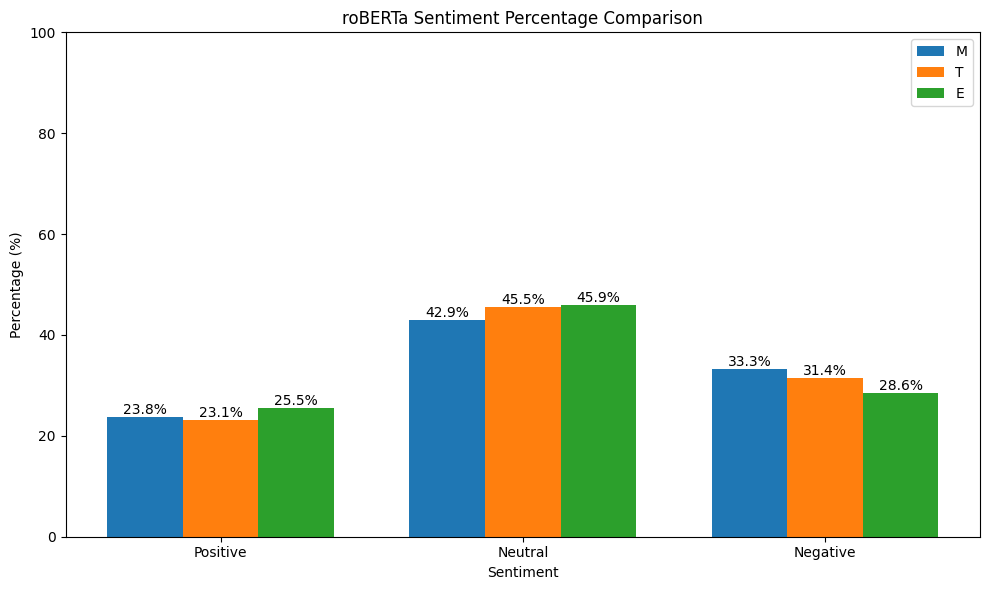

In [ ]:
labels = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(labels))
width = 0.25

percent1 = roBERTa_percent_M.reindex(labels)
percent2 = roBERTa_percent_T.reindex(labels)
percent3 = roBERTa_percent_E.reindex(labels)

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width, percent1.values, width, label="M")
bars2 = plt.bar(x, percent2.values, width, label="T")
bars3 = plt.bar(x + width, percent3.values, width, label="E")

for i in range(len(labels)):
    plt.text(x[i] - width, percent1.values[i], f"{percent1.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i], percent2.values[i], f"{percent2.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i] + width, percent3.values[i], f"{percent3.values[i]:.1f}%", ha='center', va='bottom')

plt.xticks(x, labels)

plt.title(f"roBERTa Sentiment Percentage Comparison")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()